In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Machine learning Campusx\Data\concrete_data.csv')

In [4]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [6]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train ,y_test = train_test_split(df.drop(columns= ['Strength']) , df['Strength'] , test_size=0.2 , random_state=42)

In [10]:
from sklearn.preprocessing import PowerTransformer
pf = PowerTransformer(method = 'yeo-johnson')
X_train_transformed = pf.fit_transform(X_train)
X_test_transformed = pf.transform(X_test)

In [ ]:
import scipy.stats as stats
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.distplot(X_train[col])
    plt.title(col)
    
    plt.subplot(1,2,2)
    stats.probplot(X_train[col] , dist = 'norm' , plot = plt)
    plt.title(col)
    plt.show()

In [18]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score


lr = LinearRegression()
lr.fit(X_train_transformed, y_train)
y_pred = lr.predict(X_test_transformed)

print(f"Accuracy Score {r2_score(y_test , y_pred)}")


Accuracy Score 0.8161906511066098


In [20]:
from sklearn.model_selection import cross_val_score
pt = PowerTransformer(method = 'yeo-johnson')
y = df['Strength']
X_transformed = pt.fit_transform(df.drop(columns = ['Strength']))

np.mean(cross_val_score(lr , X_transformed , y , scoring = 'r2'))

np.float64(0.6834625126992443)

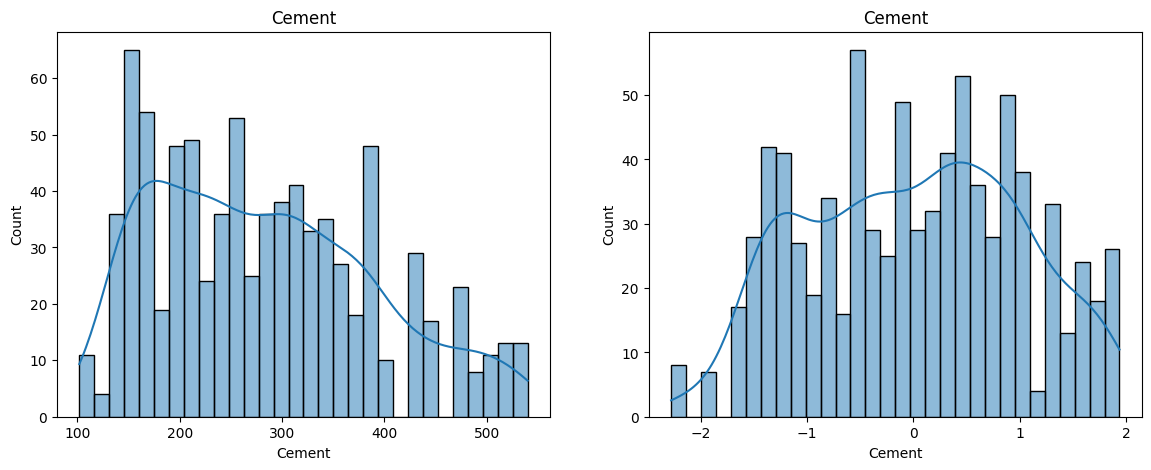

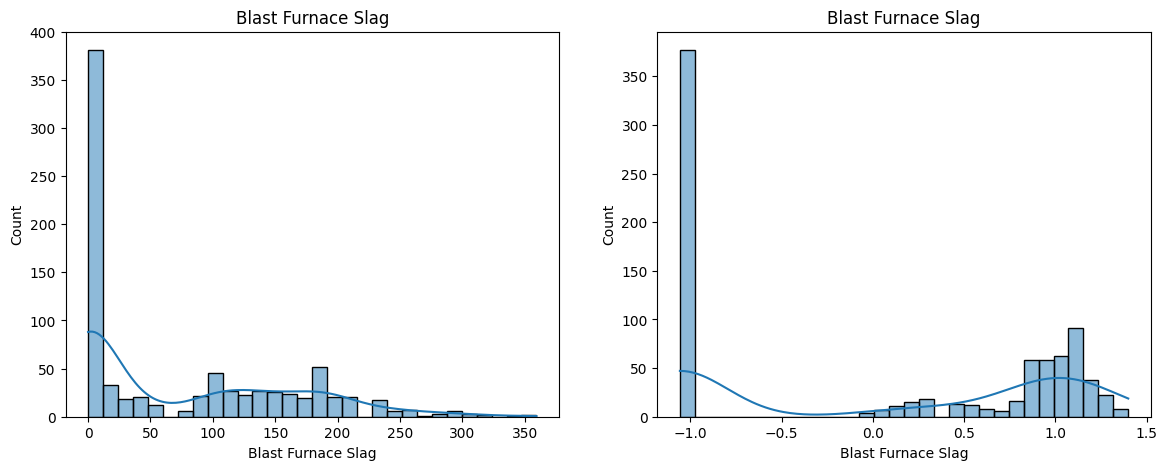

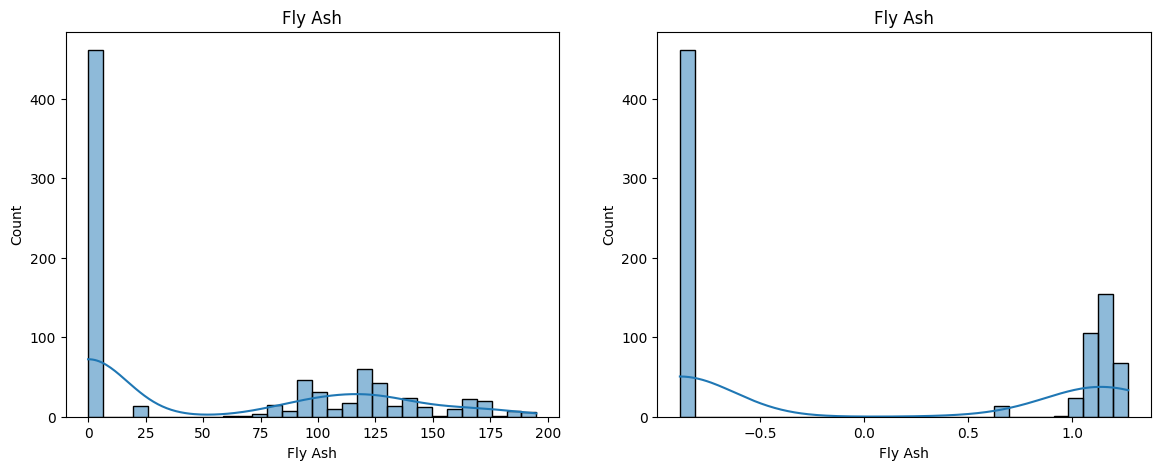

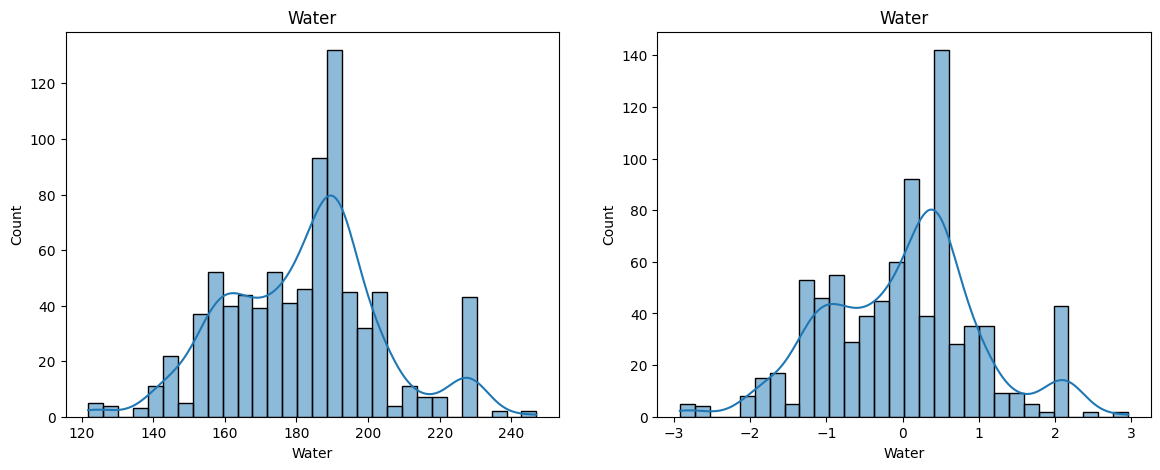

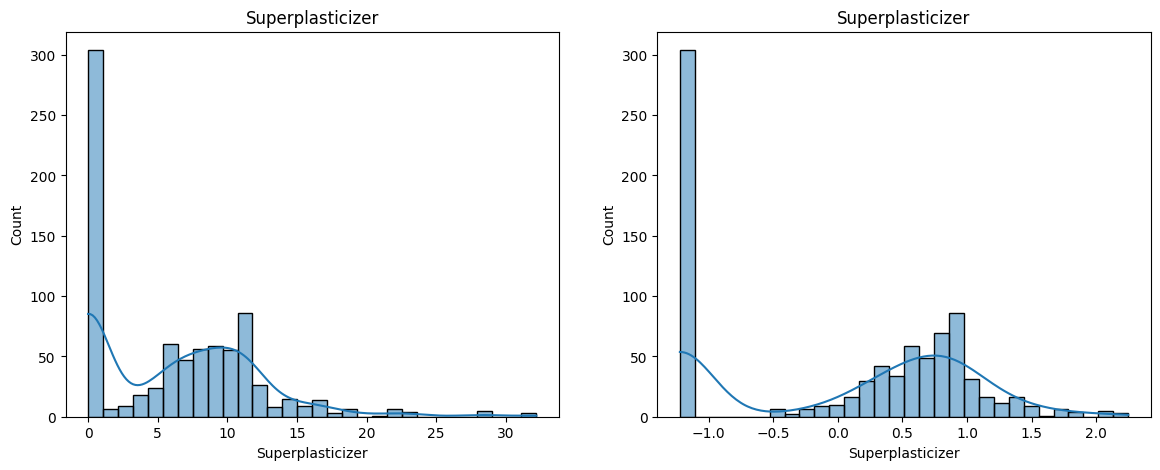

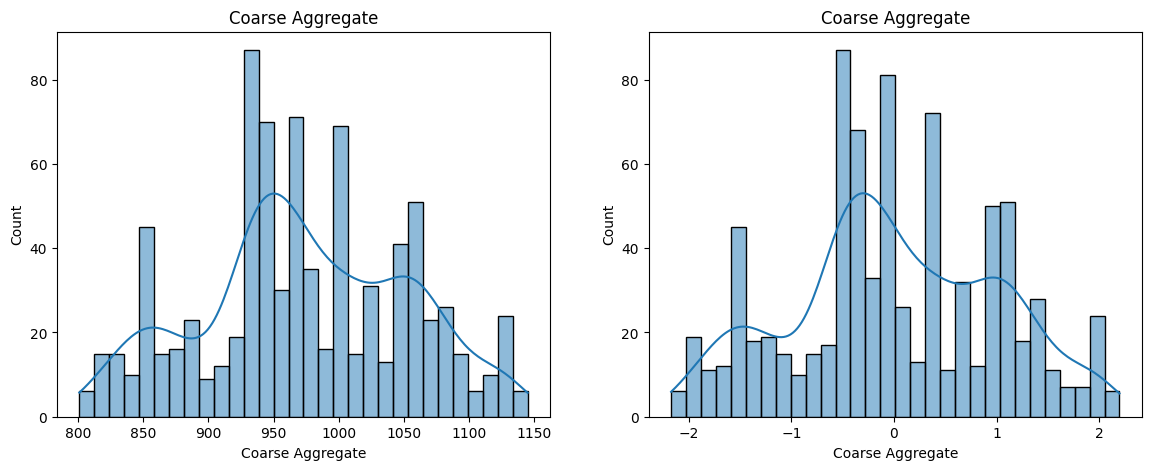

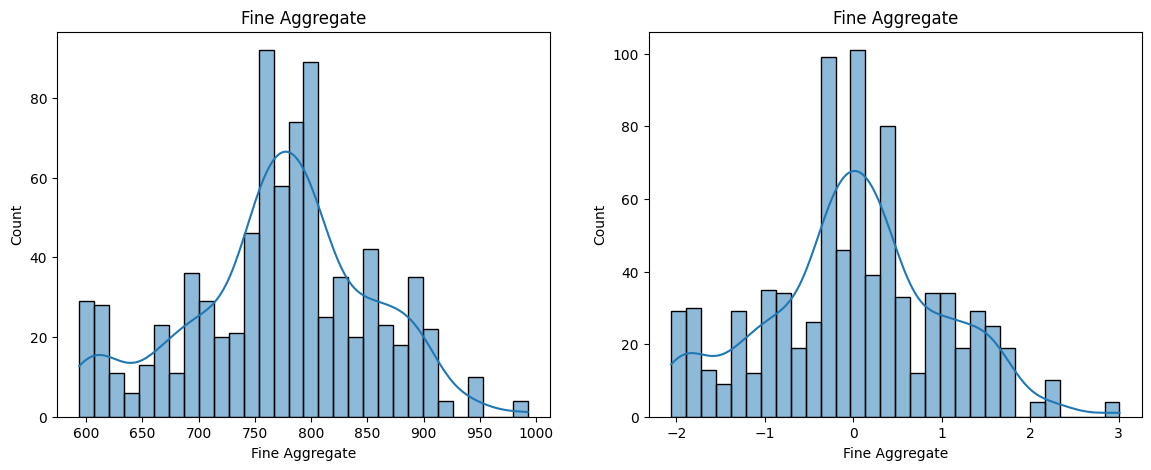

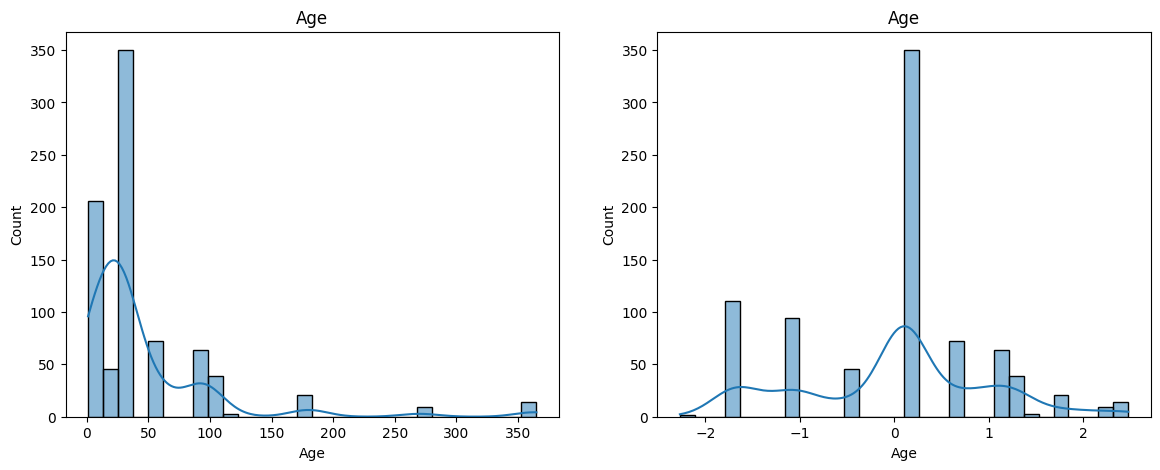

In [27]:
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    sns.histplot(data = X_train , x = col , bins = 30 , kde=True)
    plt.title(col)
    
    plt.subplot(1,2,2)
    sns.histplot(data = X_train_transformed , x = col , bins = 30 , kde=True)
    plt.title(col)
    
    plt.show()